# 🏠 UrbanNest Analytics — European Housing Intelligence
## Notebook 2: EDA + Visualisations
**Dataset:** Italian Rental Listings (Cleaned)
**Analyst:** Sahil Changotra
**Method:** pandas + matplotlib + seaborn

## Step 1: Setup + Load Clean Data

In [5]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns',None)

In [7]:
# Loading Dataset
df = pd.read_csv('../data/ha_data_clean.csv', parse_dates=['created_at'])
df_clean = df[df['is_price_outlier'] == False].copy()

In [10]:

print(f'Total rows: {len(df):,}')
print(f'Clean rows: {len(df_clean):,}')
print(f'Date range: {df_clean["created_at"].min().date()} to {df_clean["created_at"].max().date()}')
df_clean.head()


Total rows: 8,874
Clean rows: 7,689
Date range: 2016-01-02 to 2020-02-09


,city,category,country_code,created_at,price,furnished,total_size,registration_possible,washing_machine,tv,balcony,garden,terrace,is_price_outlier
0,Trento,Shared Room,it,2016-03-12 12:31:31,190.0,yes,NaN,NaN,no,yes,no,no,no,False
2,Milan,Shared Room,it,2019-10-07 10:08:21,660.0,yes,180.0,NaN,yes,NaN,NaN,NaN,NaN,False
3,Pisa,Shared Room,it,2017-07-05 11:41:57,245.0,yes,140.0,no,yes,no,NaN,no,NaN,False
4,Bologna,Private Room,it,2017-11-16 08:55:46,500.0,yes,18.0,NaN,yes,no,NaN,NaN,NaN,False
5,Pisa,Studio,it,2017-05-06 14:30:36,367.0,yes,NaN,NaN,yes,no,NaN,NaN,NaN,False


In [17]:
# Quick Data Summary

print('Category split:')
print(df_clean['category'].value_counts())
print(f'\nUnique cities: {df_clean["city"].nunique()}')
print('\nPrice summary:')
print(df_clean['price'].describe().round(2))

Category split:
category
Private Room    5173
Shared Room     1592
Apartment        487
Studio           437
Name: count, dtype: int64

Unique cities: 30

Price summary:
count    7689.00
mean      416.26
std       199.66
min        10.00
25%       275.00
50%       350.00
75%       500.00
max      1160.00
Name: price, dtype: float64


## Step 2: Price Distribution

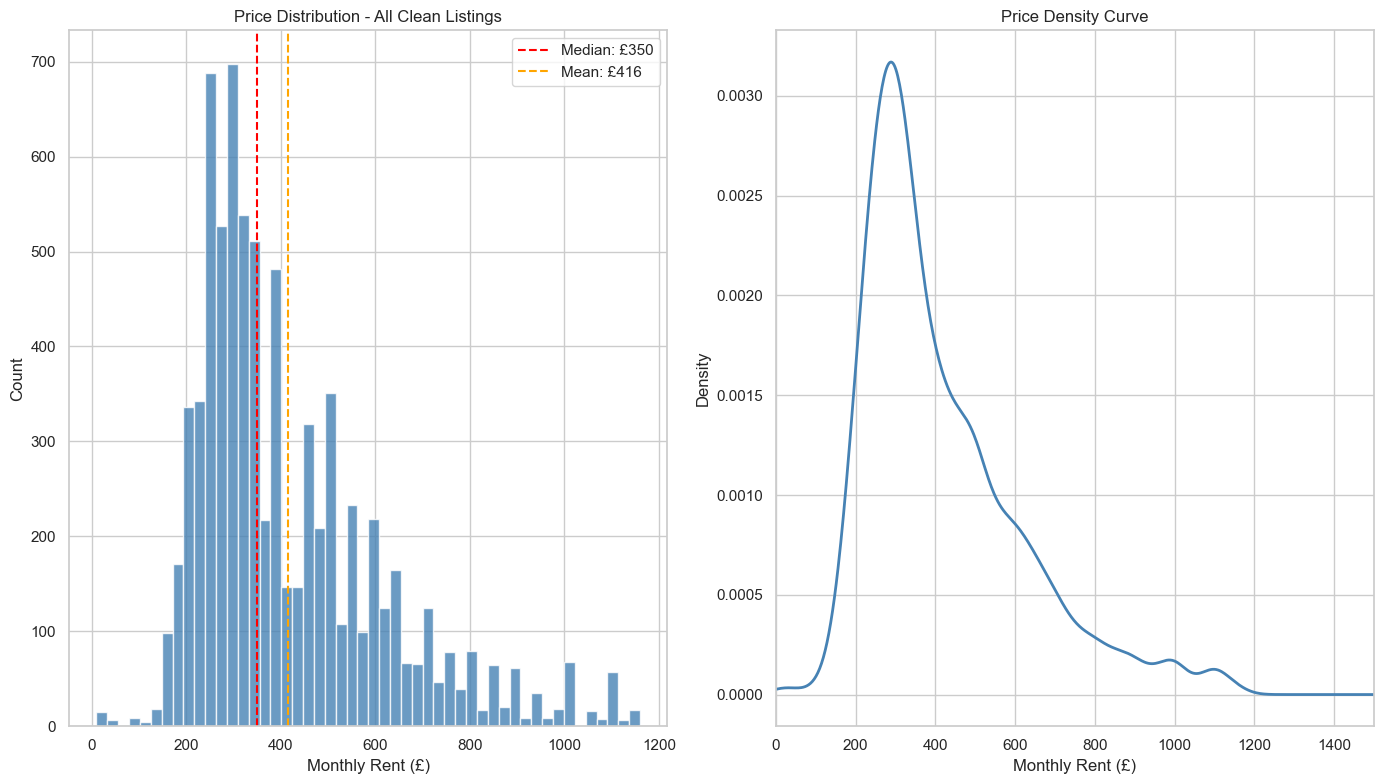

In [36]:
# Histogram + KDE

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left: Histogram
axes[0].hist(df_clean['price'], bins=50, color='steelblue',edgecolor = 'white', alpha = 0.8)
axes[0].axvline(df_clean['price'].median(),color='red',linestyle='--',
label = f'Median: £{df_clean["price"].median():.0f}')
axes[0].axvline(df_clean['price'].mean(), color='orange',linestyle='--',
label = f'Mean: £{df_clean["price"].mean():.0f}')
axes[0].set_title('Price Distribution - All Clean Listings')
axes[0].set_xlabel('Monthly Rent (£)')
axes[0].set_ylabel('Count')
axes[0].legend()


# Right KDE (smooth density curve)
df_clean['price'].plot.kde(ax = axes[1], color = 'steelblue', linewidth = 2)
axes[1].set_title('Price Density Curve')
axes[1].set_xlabel('Monthly Rent (£)')
axes[1].set_xlim(0, 1500)

plt.tight_layout()
plt.savefig('../outputs/02_price_distribution.png',dpi=150)
plt.show()


## Step 3: City Median Price Comparison

#### City Median Bar Chart

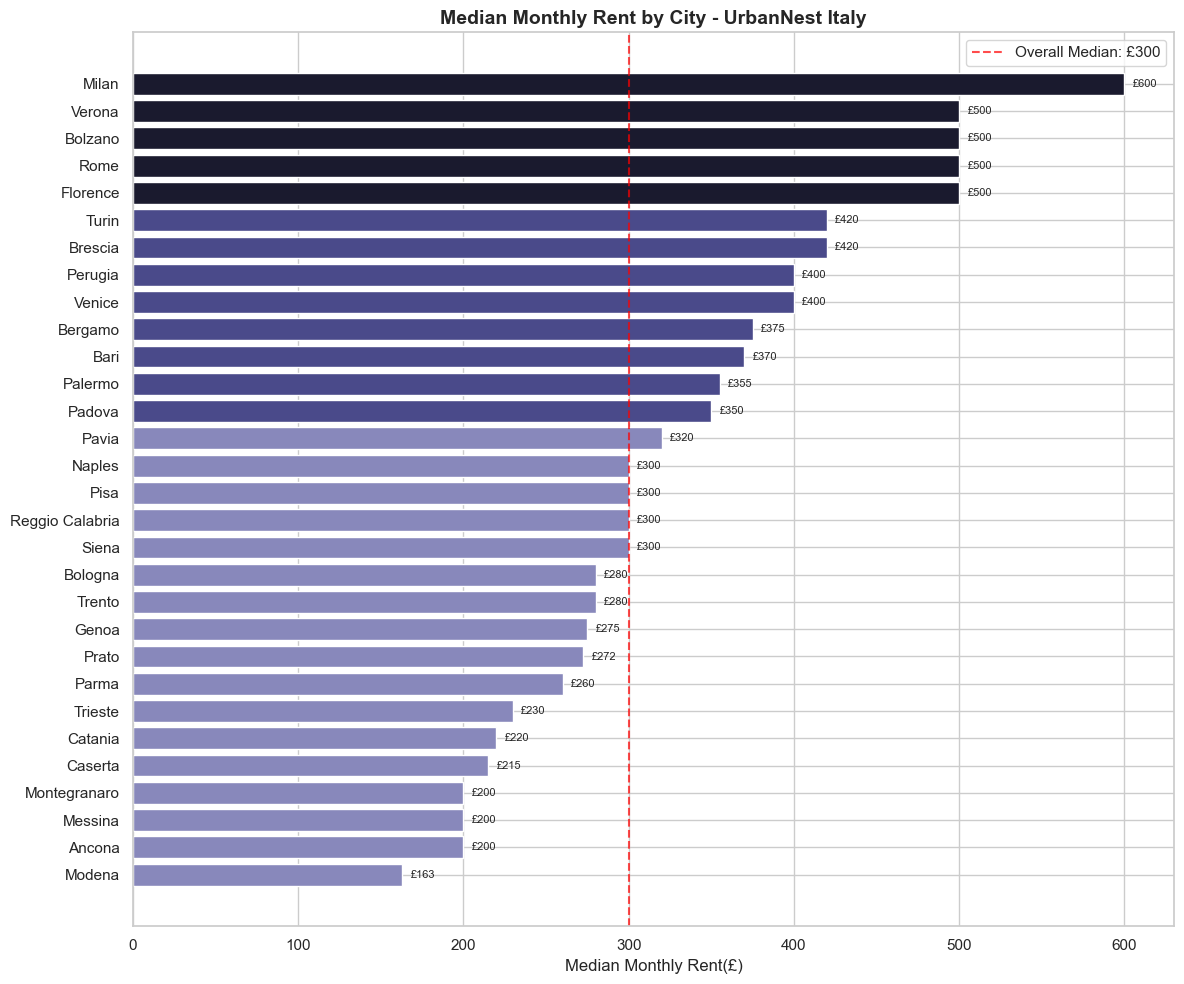

In [35]:


city_median = df_clean.groupby('city')['price'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12,10))
colors_list = ['#1a1a2e' if x >= 500 else '#4a4a8a' if x >= 350 else '#8888bb'
                for x in city_median.values]
                
bars = ax.barh(city_median.index, city_median.values, color=colors_list)
ax.axvline(city_median.median(), color = 'red',linestyle='--',alpha=0.7,
label=f'Overall Median: £{city_median.median():.0f}')

# Add value labels
for bar, val in zip(bars, city_median.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
    f'£{val:.0f}', va='center', fontsize=8)

ax.set_title('Median Monthly Rent by City - UrbanNest Italy', fontsize = 14,
fontweight = 'bold')
ax.set_xlabel('Median Monthly Rent(£)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/03_city_median_price.png',dpi=150)
plt.show()

## Category Breakdown

#### Pie Chat + Bar Chart Side by Side

In [46]:
category_counts = df_clean['category'].value_counts()
category_median = df_clean.groupby('category')['price'].median().sort_values(ascending=False)

print(f'Category Counts: \n{category_counts}')
print(f'\n')
print(f'Category Median: \n{category_median}')

Category Counts: 
category
Private Room    5173
Shared Room     1592
Apartment        487
Studio           437
Name: count, dtype: int64


Category Median: 
category
Apartment       750.0
Private Room    360.0
Studio          350.0
Shared Room     260.0
Name: price, dtype: float64


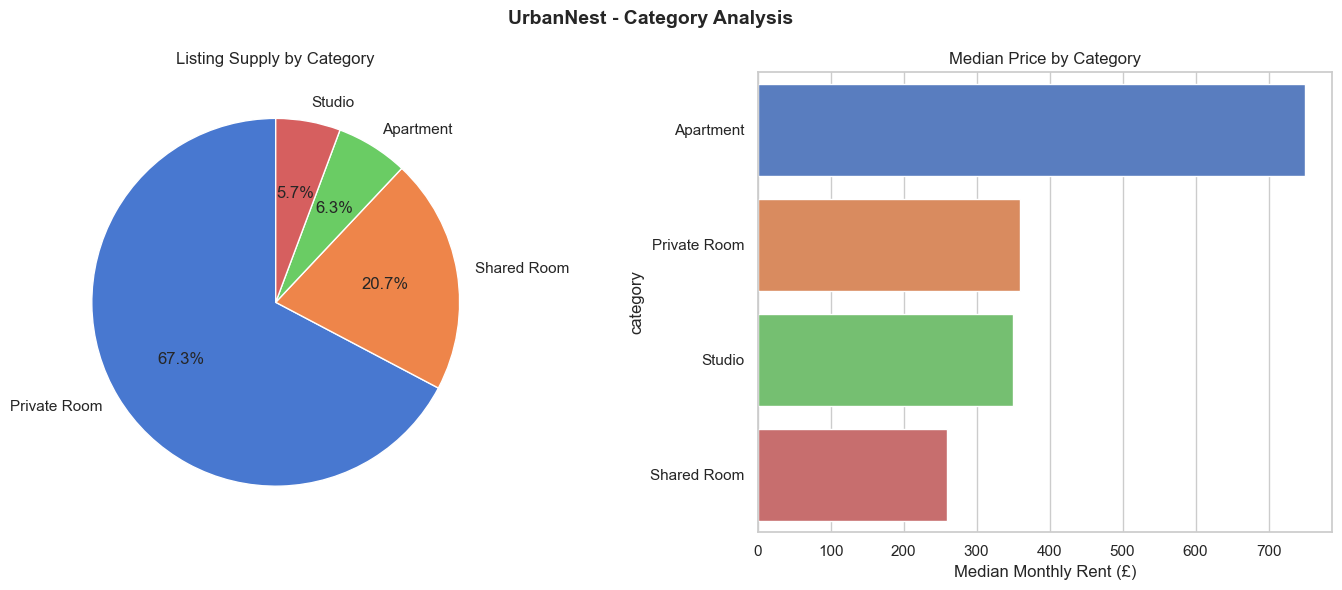

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Pie chat - supply mix
axes[0].pie(category_counts.values, labels=category_counts.index,
        autopct='%1.1f%%', startangle=90, colors = sns.color_palette('muted', len(category_counts)))
axes[0].set_title('Listing Supply by Category')

# Right: Median price by category
sns.barplot(x=category_median.values, y = category_median.index,hue=category_median.index,
ax=axes[1],palette='muted',legend=False)
axes[1].set_title('Median Price by Category')
axes[1].set_xlabel('Median Monthly Rent (£)')

plt.suptitle('UrbanNest - Category Analysis', fontsize=14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../outputs/04_category_breakdown.png', dpi=150)
plt.show()

## Furnished vs Unfurnished Price Comparison

#### Filter + Boxplot

Rows with furnished data: 4,774
furnished
yes    3980
no      794
Name: count, dtype: int64


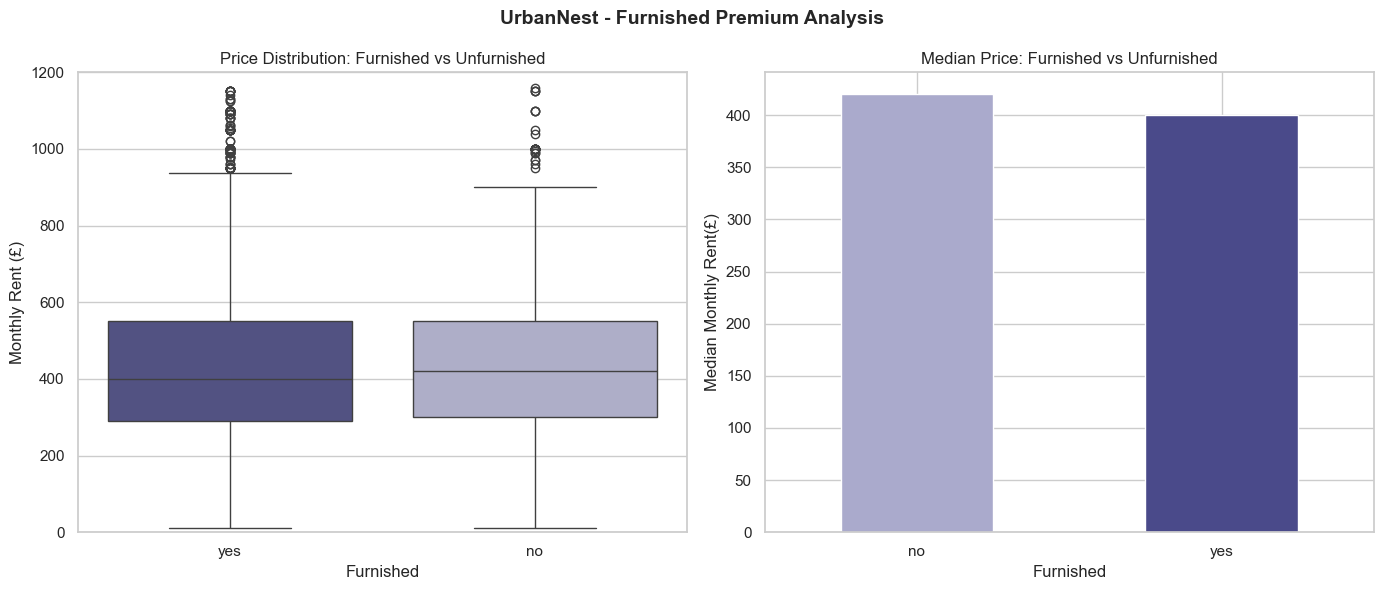

In [66]:
# Filter to rows with furnished data only
df_furnished = df_clean[df_clean['furnished'].notna()].copy()

print(f'Rows with furnished data: {len(df_furnished):,}')
print(df_furnished['furnished'].value_counts())

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# Left: Boxplot
sns.boxplot(data=df_furnished, x = 'furnished', y = 'price',hue='furnished',
    palette = {'yes':'#4a4a8a', 'no':'#aaaacc'},legend=False,
    ax=axes[0])
axes[0].set_title('Price Distribution: Furnished vs Unfurnished')
axes[0].set_xlabel('Furnished')
axes[0].set_ylabel('Monthly Rent (£)')
axes[0].set_ylim(0, 1200)

# Right : Median price comparison

furnished_median = df_furnished.groupby('furnished')['price'].median()
furnished_median.plot.bar(ax=axes[1], color = ['#aaaacc', '#4a4a8a'], edgecolor = 'white')
axes[1].set_title('Median Price: Furnished vs Unfurnished')
axes[1].set_xlabel('Furnished')
axes[1].set_ylabel('Median Monthly Rent(£)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('UrbanNest - Furnished Premium Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../outputs/05_furnished_vs_unfurnished.png', dpi=150)
plt.show()


## Step 6: Multi-Column Grouping - City x Category

#### Grouped Aggregation

In [ ]:
# Group by city + category - median price
city_cat = df_clean.groupby(['city', 'category'])['price'].median().reset_index()
city_cat.columns = ['city','category','median_price']

In [68]:
city_cat

,city,category,median_price
0,Ancona,Apartment,245.0
1,Ancona,Private Room,200.0
2,Ancona,Shared Room,150.0
3,Ancona,Studio,310.0
4,Bari,Apartment,300.0
...,...,...,...
93,Venice,Studio,690.0
94,Verona,Apartment,750.0
95,Verona,Private Room,425.0
96,Verona,Shared Room,230.0


In [71]:
# Filter to top 8 cities by listing count
top_cities = df_clean['city'].value_counts().head(8).index.tolist()
city_cat_top = city_cat[city_cat['city'].isin(top_cities)]

print(f'Combinations: {len(city_cat_top)}')
print(city_cat_top.sort_values('median_price', ascending=False).head(10))

Combinations: 32
        city      category  median_price
27  Florence     Apartment         990.0
36     Milan     Apartment         900.0
39     Milan        Studio         885.0
71      Rome     Apartment         760.0
86     Turin     Apartment         620.0
37     Milan  Private Room         620.0
75     Siena     Apartment         600.0
64      Pisa     Apartment         600.0
10   Bologna     Apartment         565.0
79    Trento     Apartment         550.0


#### Heatmap: City x Category

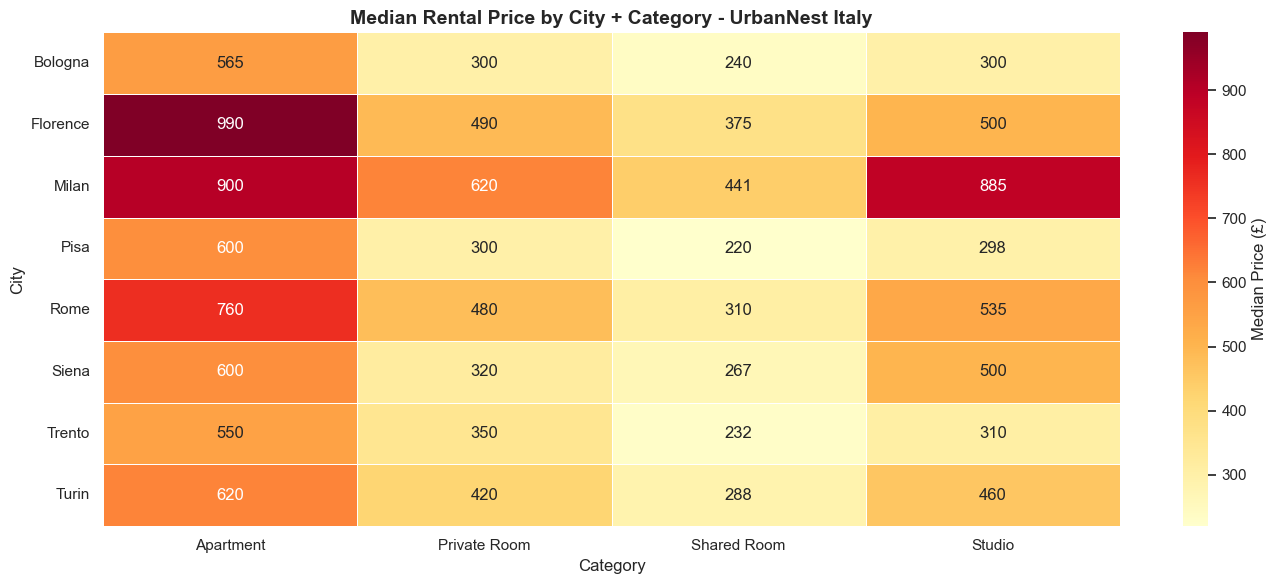

In [74]:
# pivot for heatmap
pivot = city_cat_top.pivot(index='city',columns='category', values='median_price')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax,
cbar_kws= {'label':'Median Price (£)'})

ax.set_title('Median Rental Price by City + Category - UrbanNest Italy',
fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('City')
plt.tight_layout()
plt.savefig('../outputs/06_city_category_heatmap.png',dpi=150)
plt.show()

## Step 7: Supply Trend Over Time

#### Montly Listings Counts

In [76]:
# Monthly listings counts
df_clean['year_month'] = df_clean['created_at'].dt.to_period('M')
monthly = df_clean.groupby('year_month').size().reset_index(name='listings')
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

print(f'Months in dataset: {len(monthly)}')
print(monthly.head())

Months in dataset: 50
  year_month  listings year_month_dt
0    2016-01       176    2016-01-01
1    2016-02       129    2016-02-01
2    2016-03       153    2016-03-01
3    2016-04       181    2016-04-01
4    2016-05       290    2016-05-01


#### Supply Trend Line Chart

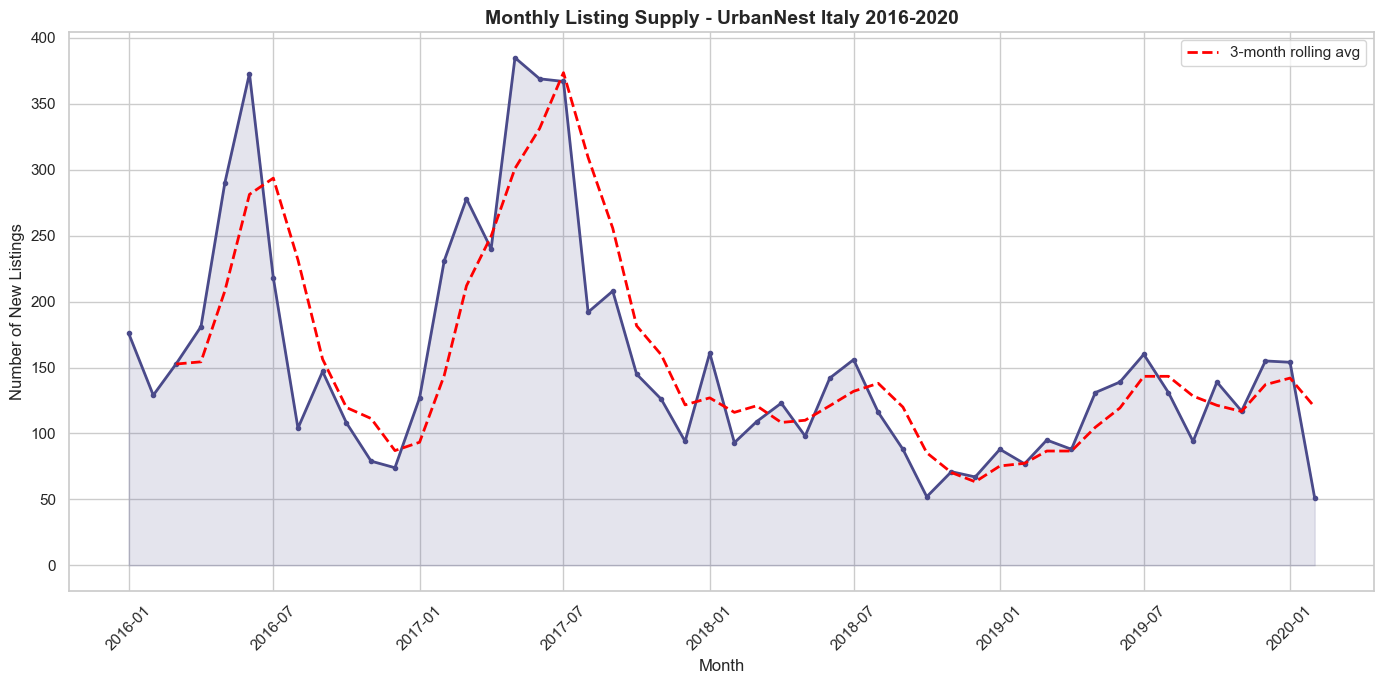

In [77]:
fig, ax = plt.subplots(figsize=(14,7))

ax.plot(monthly['year_month_dt'], monthly['listings'],
color='#4a4a8a', linewidth=2, marker='o', markersize=3)

ax.fill_between(monthly['year_month_dt'], monthly['listings'],
alpha=0.15, color='#4a4a8a')

# Add 3-month rolling average
monthly['rolling_avg'] = monthly['listings'].rolling(3).mean()

ax.plot(monthly['year_month_dt'], monthly['rolling_avg'],
color = 'red',linewidth=2,linestyle = '--',label='3-month rolling avg' )

ax.set_title('Monthly Listing Supply - UrbanNest Italy 2016-2020', fontsize = 14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of New Listings')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/07_supply_trend.png',dpi=150)
plt.show()

## Outlier Impact Analysis

#### Side-by-Side Comparison

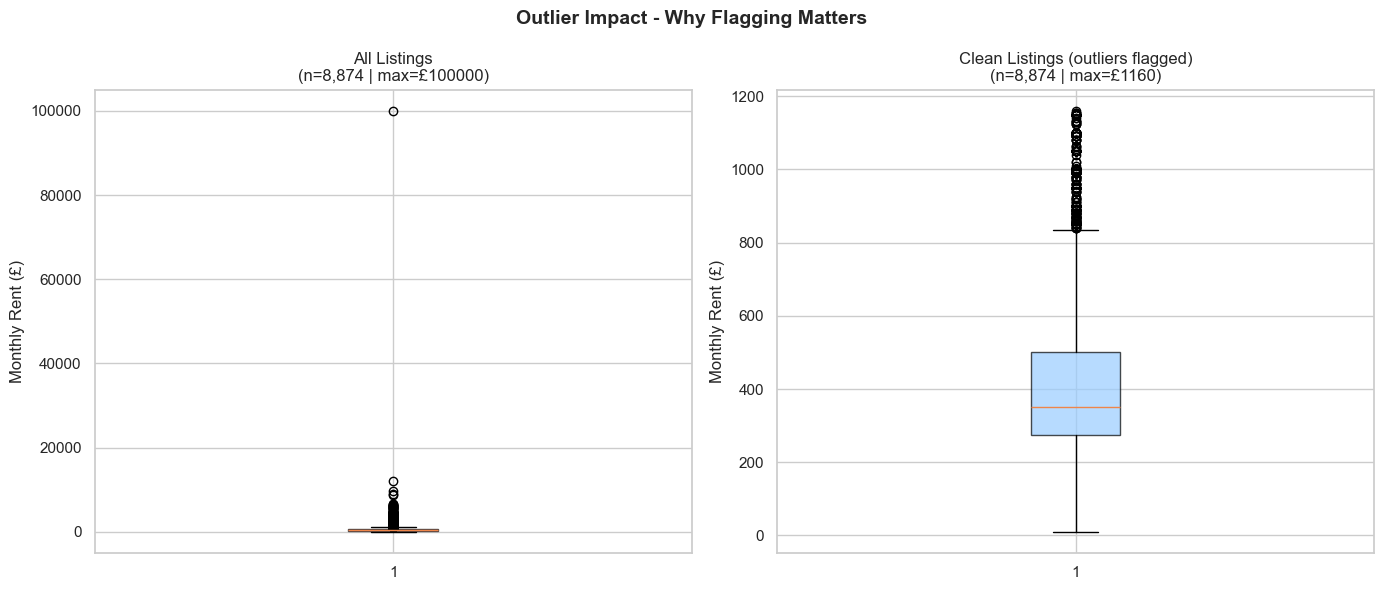

In [80]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

# All data (including outliers)

axes[0].boxplot(df['price'].dropna(), vert=True,patch_artist=True,
boxprops=dict(facecolor='#ff9999', alpha=0.7))

axes[0].set_title(f'All Listings\n(n={len(df):,} | max=£{df['price'].max():.0f})')
axes[0].set_ylabel('Monthly Rent (£)')

# Clean data (Outliers removed)

axes[1].boxplot(df_clean['price'].dropna(), vert=True, patch_artist=True,
boxprops = dict(facecolor='#99ccff', alpha=0.7))

axes[1].set_title(f'Clean Listings (outliers flagged)\n(n={len(df):,} | max=£{df_clean["price"].max():.0f})')
axes[1].set_ylabel('Monthly Rent (£)')

plt.suptitle('Outlier Impact - Why Flagging Matters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/08_outlier_comparison.png',dpi=150)
plt.show()

In [81]:
import os

In [83]:
output_files = os.listdir('../outputs/')
print('Files saved to outputs/:')
for f in sorted(output_files):
    print(f' ■ {f}')
    print(f'\nTotal charts: {len([f for f in output_files if f.endswith(".png")])}')

Files saved to outputs/:
 ■ 01_missing_values.png

Total charts: 8
 ■ 02_price_distribution.png

Total charts: 8
 ■ 03_city_median_price.png

Total charts: 8
 ■ 04_category_breakdown.png

Total charts: 8
 ■ 05_furnished_vs_unfurnished.png

Total charts: 8
 ■ 06_city_category_heatmap.png

Total charts: 8
 ■ 07_supply_trend.png

Total charts: 8
 ■ 08_outlier_comparison.png

Total charts: 8
